## RNA Gene Expression Plots

### Load in RNA Data

Loads CosMX RNA expression data. Will take several minutes

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

#Load files on Lab computer
# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAexpression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAmetadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\RNAumap.csv", index_col=0)

#Load files on laptop
expr= pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMAA_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMAA_meta_transposed.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMAA_umap_transposed.csv", index_col=0)

# Display General Data on the imported data. Run the import first
display(expr.columns)
display(expr.index)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata.obsm["X_umap"] = umap.values

C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
C:\Users\evanj\anaconda3\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning

Index(['ABL1', 'ABL2', 'ACE', 'ACE2', 'ACKR1', 'ACKR3', 'ACKR4', 'ACTA2',
       'ACTG2', 'ACVR1',
       ...
       'NegPrb13', 'NegPrb14', 'NegPrb15', 'NegPrb16', 'NegPrb18', 'NegPrb19',
       'NegPrb20', 'NegPrb21', 'NegPrb22', 'NegPrb23'],
      dtype='object', length=978)

Index(['__Run5607.TMAA_1_1', '__Run5607.TMAA_2_1', '__Run5607.TMAA_3_1',
       '__Run5607.TMAA_4_1', '__Run5607.TMAA_5_1', '__Run5607.TMAA_6_1',
       '__Run5607.TMAA_7_1', '__Run5607.TMAA_8_1', '__Run5607.TMAA_9_1',
       '__Run5607.TMAA_10_1',
       ...
       '__Run5607.TMAA_3593_25', '__Run5607.TMAA_3594_25',
       '__Run5607.TMAA_3595_25', '__Run5607.TMAA_3597_25',
       '__Run5607.TMAA_3599_25', '__Run5607.TMAA_3600_25',
       '__Run5607.TMAA_3601_25', '__Run5607.TMAA_3602_25',
       '__Run5607.TMAA_3603_25', '__Run5607.TMAA_3604_25'],
      dtype='object', length=85390)

### Plot mRNA gene expression in a cell

Should be a good way to visuallize where genes are expressed spatially. 

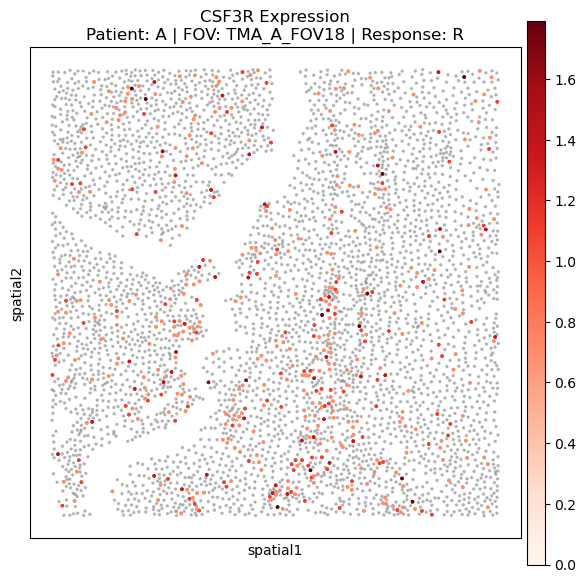

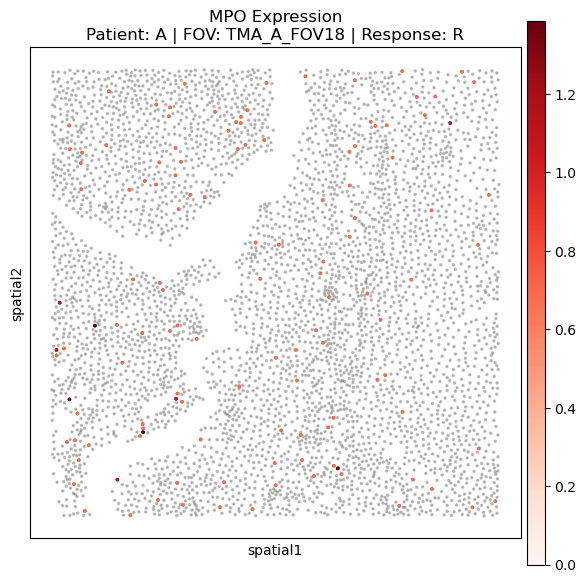

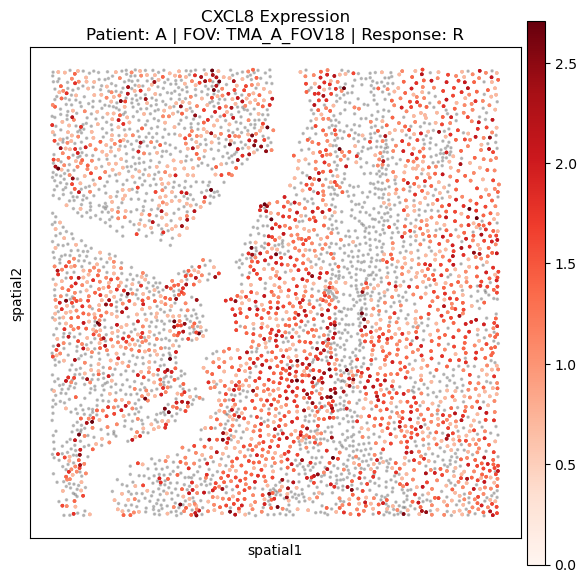

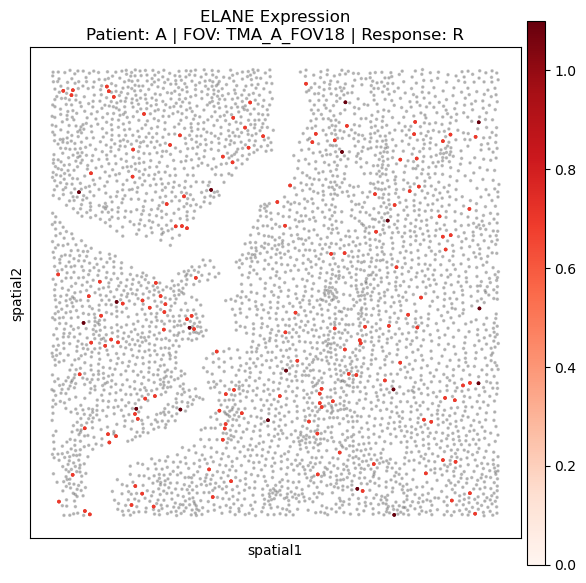

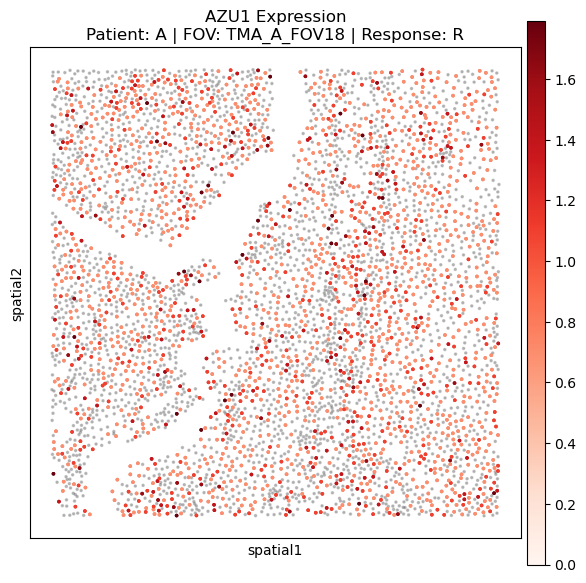

⚠️ Gene CEACAM8 not found in dataset. Skipping.


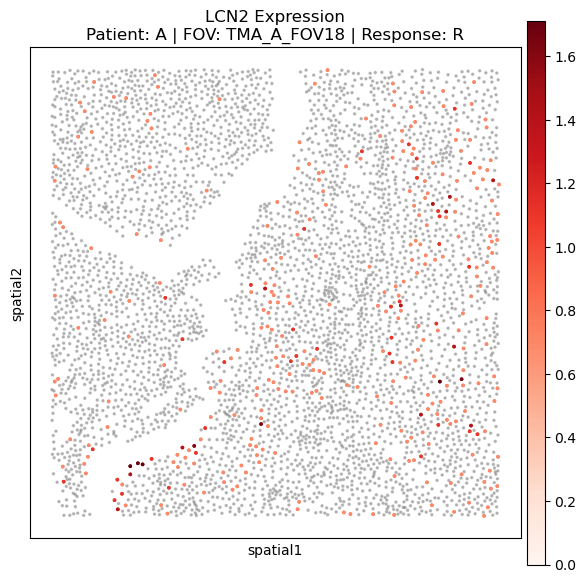

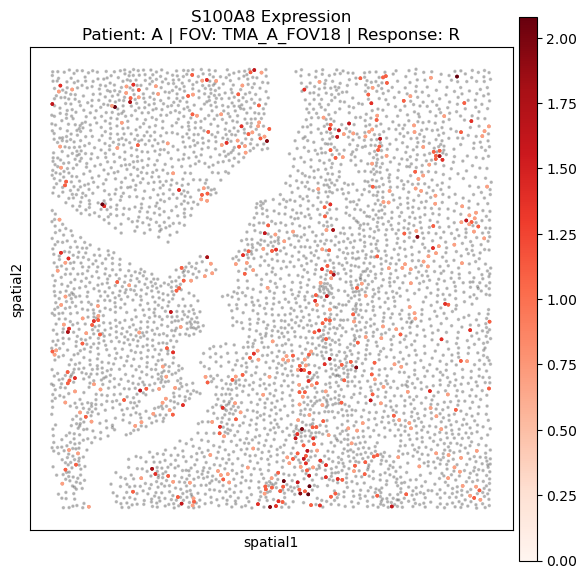

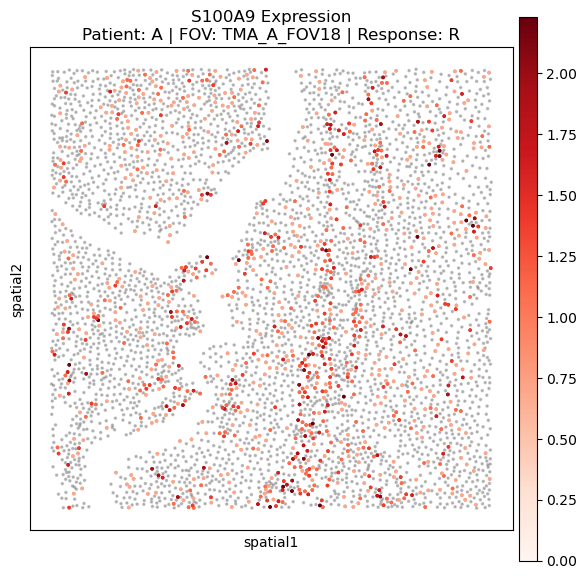

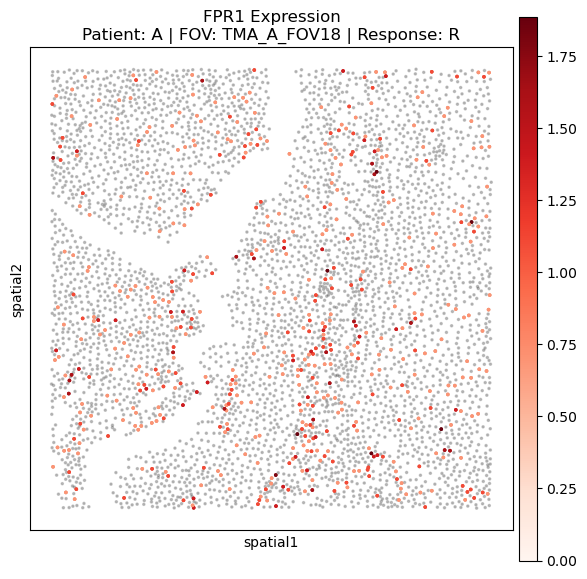

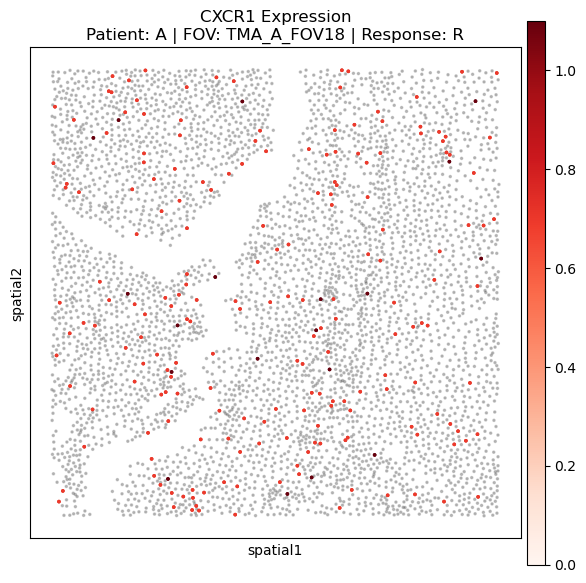

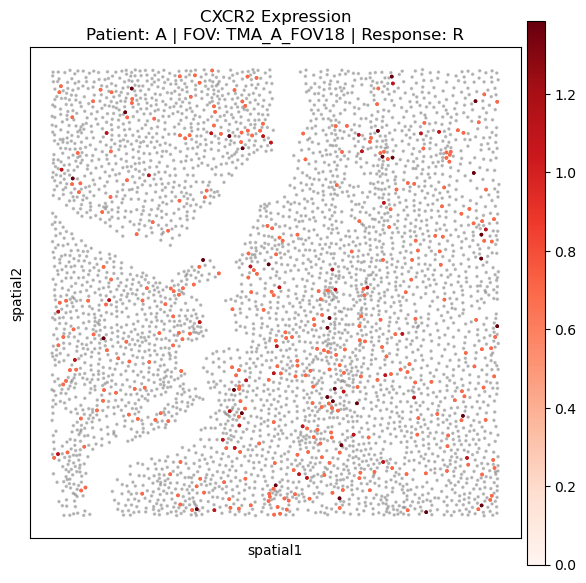

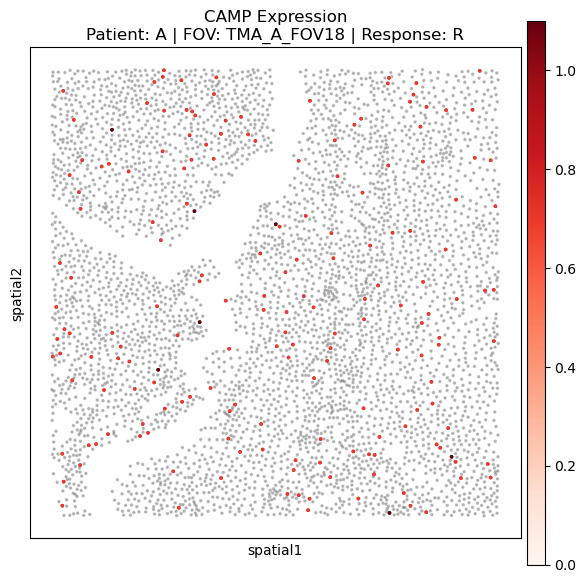

In [5]:
import my_functions
import squidpy as sq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

genes_to_plot = [
    "CSF3R",  # Granulocyte Colony-Stimulating Factor Receptor
    "MPO",    # Myeloperoxidase
    "ELANE",  # Neutrophil elastase
    "AZU1",   # Azurocidin
    "CEACAM8",# CD66b
    "LCN2",   # Lipocalin 2
    "S100A8", # Calgranulin A
    "S100A9", # Calgranulin B
    "FPR1",   # Formyl Peptide Receptor 1
    "CXCR1",  # IL-8 Receptor A
    "CXCR2",  # IL-8 Receptor B
    "CAMP"    # Cathelicidin Antimicrobial Peptide
]

import squidpy as sq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

cell_ID_like = r"TMA_A_FOV18" #(?!\d)
genes_to_plot = [
    "CSF3R", "MPO", "CXCL8", "ELANE", "AZU1", "CEACAM8", "LCN2",
    "S100A8", "S100A9", "FPR1", "CXCR1", "CXCR2", "CAMP"
]

# Subset sample
subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
patient_id = subset.obs["PatientID"].unique()[0]
response_status = subset.obs["Response"].unique()[0]
subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")

for gene in genes_to_plot:
    if gene not in adata.var_names:
        print(f"⚠️ Gene {gene} not found in dataset. Skipping.")
        continue

    # Get expression values
    gene_values = subset[:, gene].X
    if hasattr(gene_values, "toarray"):
        gene_values = gene_values.toarray().flatten()
    else:
        gene_values = gene_values.flatten()

    subset.obs[f"{gene}_expression"] = gene_values
    subset.obs["expr_mask"] = gene_values > 0

    fig, ax = plt.subplots(figsize=(6, 6))

    # Background: all cells faint
    sq.pl.spatial_scatter(
        subset,
        color=None,
        shape=None,
        size=10,
        ax=ax,
        alpha=0.1
    )

    # Overlay: expressing cells in color
    vmax = np.percentile(gene_values[gene_values > 0], 99)
    sq.pl.spatial_scatter(
        subset[subset.obs["expr_mask"]],
        color=f"{gene}_expression",
        shape=None,
        size=10,
        ax=ax,
        cmap="Reds",  # You can use 'plasma', 'viridis', etc.
        vmin=0,
        vmax=vmax  # Set based on expected expression range
    )

    ax.invert_yaxis()
    ax.set_title(f"{gene} Expression\nPatient: {patient_id} | FOV: {cell_ID_like} | Response: {response_status}")

    plt.tight_layout()
    plt.show()



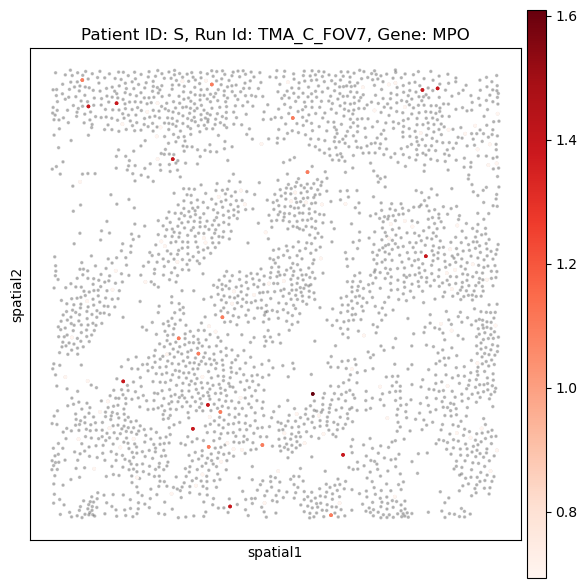

In [34]:
import squidpy as sq
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

cell_ID_like = r"TMA_C_FOV7"
mapping_gene = "MPO"

# Subset sample
subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
patient_id = subset.obs["PatientID"].unique()[0]
response_status = subset.obs["Response"].unique()[0]

# Ensure categorical cluster
subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")

# Get gene expression
gene_values = subset[:, mapping_gene].X
if hasattr(gene_values, "toarray"):
    gene_values = gene_values.toarray().flatten()
else:
    gene_values = gene_values.flatten()
subset.obs[f"{mapping_gene}_expression"] = gene_values

# Create mask for expressing cells
subset.obs["expr_mask"] = gene_values > 0

# --- PLOTTING ---

fig, ax = plt.subplots(figsize=(6, 6))

# Plot all cells in gray as background
sq.pl.spatial_scatter(
    subset,
    color=None,
    shape=None,
    size=10,
    ax=ax,
    alpha=0.1
)

# Overlay expressing cells with vivid color
sq.pl.spatial_scatter(
    subset[subset.obs["expr_mask"]],
    color=f"{mapping_gene}_expression",
    shape=None,
    size=10,
    ax=ax,
    cmap="Reds",
)

# Flip Y-axis to match histological orientation
ax.invert_yaxis()

# Add title manually
ax.set_title(f"Patient ID: {patient_id}, Run Id: {cell_ID_like}, Gene: {mapping_gene}")

plt.tight_layout()
plt.show()


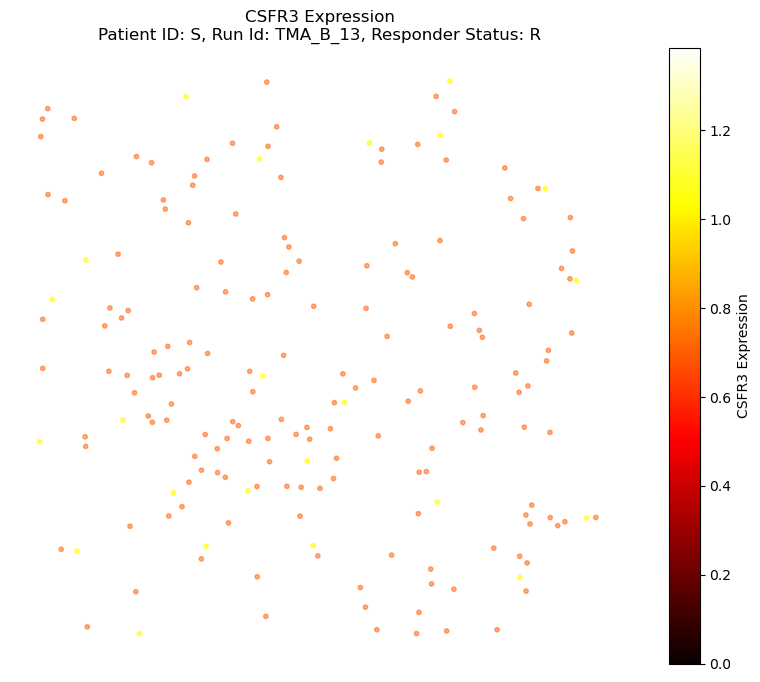

In [38]:
import matplotlib.pyplot as plt

# Get coordinates and expression values
coords = subset.obsm["spatial"]
expression = subset[:, "CSF3R"].X.toarray().flatten()  # or .X if dense

# Normalize expression to [0, 1] for alpha or color scaling
norm_expr = (expression - expression.min()) / (expression.max() - expression.min())

# Plot manually
plt.figure(figsize=(10, 8))
plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=expression,
    cmap="hot",           # or custom cmap
    s=10
 #   alpha=norm_expr,      # makes low-expressers fade out
)
plt.gca().invert_yaxis()
plt.colorbar(label="CSFR3 Expression")
plt.title(f"CSFR3 Expression\nPatient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status: {response_status}")
plt.axis("off")
plt.show()

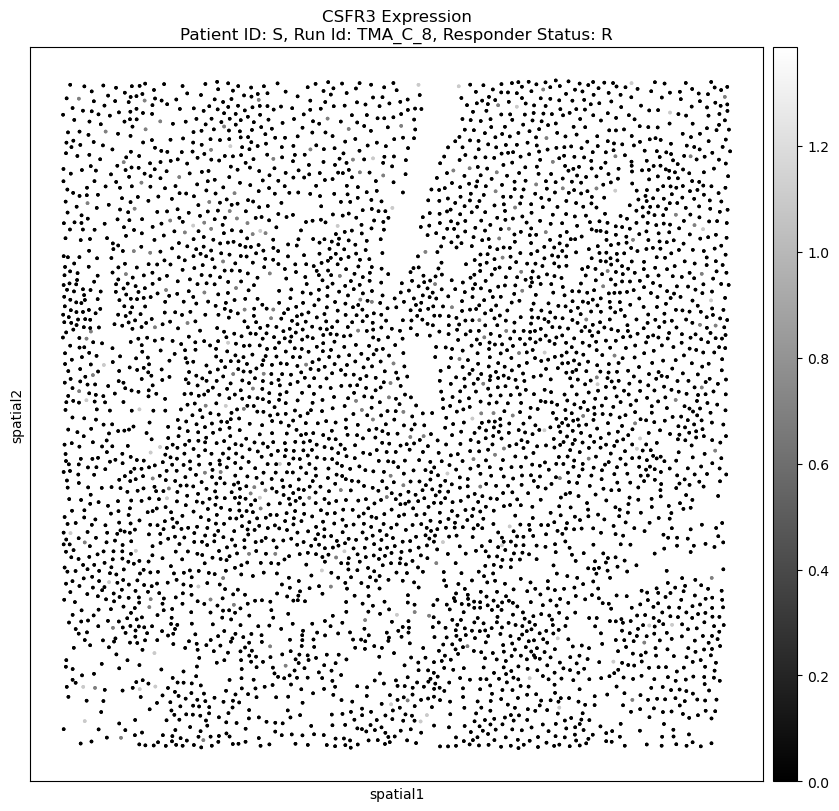

In [39]:
TMA_ids = ["C"]

for j in TMA_ids:
    for i in range(8, 9):
        cell_ID_like = f"TMA_{j}_FOV{i}(?!\d)"
        subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
        
        # Skip if no matching cells are found
        if subset.n_obs == 0:
            continue

        # Get the unique patient ID (assumes only one per subset)
        patient_id = subset.obs["PatientID"].unique()[0]
        response_status = subset.obs["Response"].unique()[0]

        # Plot expression of CSFR3
        sq.pl.spatial_scatter(
            subset,
            shape=None,
            color="CD36",  # this will plot expression levels of CSFR3
            size=10,
            title=f"CSFR3 Expression\nPatient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status: {response_status}",
            figsize=(10, 8),
            cmap="grey",  # or "magma", "plasma", "hot" etc. for brighter colors
            vmin=0,          # optional: clamp lower bound
            vmax=None,       # optional: clamp upper bound
            colorbar=True,   # show the expression color scale
        )

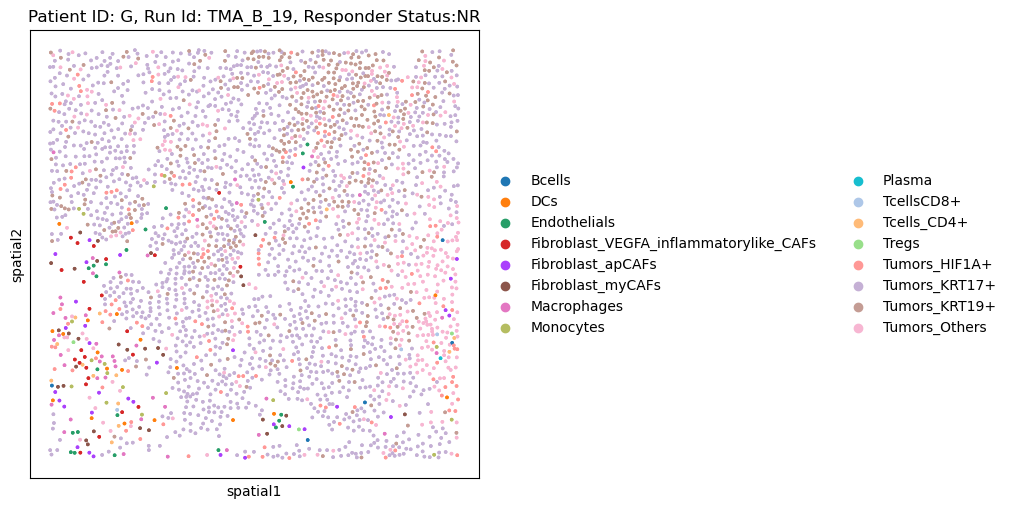

In [47]:
import squidpy as sq
import warnings
warnings.filterwarnings("ignore")

# Color scheme
BCELL_COLOR = "#48631d"
CD4_COLOR = "#42f5f5"
CD8_COLOR = "#4248f5"
DCs_COLOR = "#edbbbb"
FIBROBLASTS_COLOR = "#b08c68"
MACROPHAGE_COLOR = "#181459"
MONOCYTES_COLOR = "#1a8a2d"
NK_COLOR = "#f542bf"
PLASMA_COLOR = "#ec42f5"
TREG_COLOR = "#424ef5"
TUMOR_COLOR = "#57eba3"
ENDO_COLOR = "#b0a287"
OTHER_COLOR = "#d9d9d9"
FIBROBLAST_VEGFA_COLOR = "#b08c68"
FIBROBLAST_APCAFS_COLOR = "#b08c68"
FIBROBLAST_MYCAFS_COLOR = "#b08c68"
TUMORS_HIF1A_COLOR = "#57eba3"
TUMORS_KRT17_COLOR = "#57eba3"
TUMORS_KRT19_COLOR = "#57eba3"
TUMORS_OTHER_COLOR = "#57eba3"

# Full color mapping
cell_type_colors = {
    "Bcells": BCELL_COLOR,
    "TcellsCD8+": CD4_COLOR,
    "Tcells_CD4+": CD8_COLOR,
    "DCs": DCs_COLOR,
    "Fibroblasts/SMCs": FIBROBLASTS_COLOR,
    "Macrophages": MACROPHAGE_COLOR,
    "Monocytes": MONOCYTES_COLOR,
    "NK_cells": NK_COLOR,
    "Plasma": PLASMA_COLOR,
    "Tregs": TREG_COLOR,
    "Endothelials": ENDO_COLOR,
    "Fibroblast_myCAFs": FIBROBLAST_MYCAFS_COLOR,
    "Fibroblast_apCAFs": FIBROBLAST_APCAFS_COLOR,
    "Fibroblast_VEGFA_inflammatorylike_CAFs": FIBROBLAST_VEGFA_COLOR,
    "Tumors_HIF1A+": TUMORS_HIF1A_COLOR,
    "Tumors_KRT17+": TUMORS_KRT17_COLOR,
    "Tumors_KRT19+": TUMORS_KRT19_COLOR,
    "Tumors_Others": TUMORS_OTHER_COLOR
}

TMA_ids=["B"]

for j in TMA_ids:
    for i in range(19, 20):
        cell_ID_like =f"TMA_{j}_FOV{i}(?!\d)"
        subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]
        
        # Skip if no matching cells are found
        if subset.n_obs == 0:
            continue
    
        # Get the unique patient ID (assumes only one per subset)
        patient_id = subset.obs["PatientID"].unique()[0]
        response_status = subset.obs["Response"].unique()[0]

        # Convert to categorical without setting all 12 types
        subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")
        
        # Plot with dynamic title
        sq.pl.spatial_scatter(
            subset,
            shape=None,
            color="annot_cluster2",
            size=10,
            title=f"Patient ID: {patient_id}, Run Id: TMA_{j}_{i}, Responder Status:{response_status}",
            figsize=(10, 8),  # or larger
            legend_loc='right margin'  # move legend out of plot area
        )

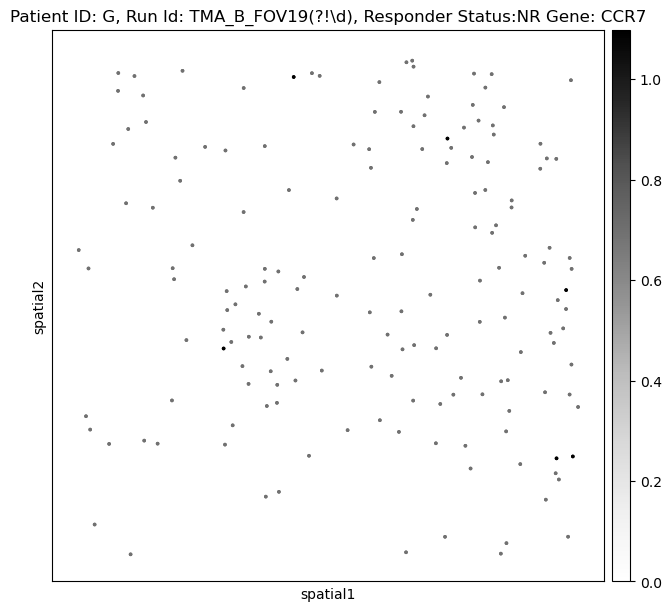

In [48]:
import squidpy as sq
import warnings
import my_functions
warnings.filterwarnings("ignore")


cell_ID_like =f"TMA_B_FOV19(?!\d)"
mapping_gene="CCR7"


subset = adata[adata.obs.tma_fov_id.str.contains(cell_ID_like)]

# Get the unique patient ID (assumes only one per subset)
patient_id = subset.obs["PatientID"].unique()[0]
response_status = subset.obs["Response"].unique()[0]

# Convert to categorical without setting all 12 types
subset.obs["annot_cluster2"] = subset.obs["annot_cluster2"].astype("category")

# Get gene expression and store in obs
gene_values = subset[:, mapping_gene].X
if hasattr(gene_values, "toarray"):  # handle sparse matrix
    gene_values = gene_values.toarray().flatten()
else:
    gene_values = gene_values.flatten()

subset.obs[f"{mapping_gene}_expression"] = gene_values

# Plot with assigned colors
sq.pl.spatial_scatter(
    subset,
    shape=None,
    color=f"{mapping_gene}_expression",
    size=10,
    figsize=(8, 6), 
    cmap="Greys",  # optional: you can change color map
    title=f"Patient ID: {patient_id}, Run Id: {cell_ID_like}, Responder Status:{response_status} Gene: {mapping_gene}"
        )